In [ ]:

import pandas as pd
import numpy as np

# Feature engineering for text data
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Saving and loading files
import pickle
from scipy.sparse import save_npz, load_npz

# Visualization
import matplotlib.pyplot as plt

# File/path handling
import os

In [ ]:
import pandas as pd

df = pd.read_csv(
    "preprocessed_dataset.csv",
    low_memory=False
)

print("Dataset shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


display(df.head())

Dataset shape: (287421, 12)

Column Names:
['id', 'title', 'category', 'category_code', 'published_date', 'updated_date', 'authors', 'first_author', 'summary', 'summary_word_count', 'combined_text', 'cleaned_text']


,id,title,category,category_code,published_date,updated_date,authors,first_author,summary,summary_word_count,combined_text,cleaned_text
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,cs.AI,1993-08-01,1993-08-01,['M. L. Ginsberg'],'M. L. Ginsberg',Because of their occasional need to return to ...,79,dynamic backtracking occasional need return sh...,dynamic backtrack occasional need return shall...
1,cs-9308102v1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,cs.AI,1993-08-01,1993-08-01,['M. P. Wellman'],'M. P. Wellman',Market price systems constitute a well-underst...,119,market oriented programming environment applic...,market orient program environment application ...
2,cs-9309101v1,An Empirical Analysis of Search in GSAT,Artificial Intelligence,cs.AI,1993-09-01,1993-09-01,"['I. P. Gent', 'T. Walsh']",'I. P. Gent',We describe an extensive study of search in GS...,167,empirical analysis search gsat describe extens...,empirical analysis search gsat describe extens...
3,cs-9311101v1,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,cs.AI,1993-11-01,1993-11-01,"['F. Bergadano', 'D. Gunetti', 'U. Trinchero']",'F. Bergadano',As real logic programmers normally use cut (!)...,174,difficulties learning logic programs cut real ...,difficulty learn logic program cut real logic ...
4,cs-9311102v1,Software Agents: Completing Patterns and Const...,Artificial Intelligence,cs.AI,1993-11-01,1993-11-01,"['J. C. Schlimmer', 'L. A. Hermens']",'J. C. Schlimmer',To support the goal of allowing users to recor...,187,software agents completing patterns constructi...,software agent complete pattern construct user...


In [ ]:

# Inspect cleaned_text Column
if "cleaned_text" in df.columns:
    print("'cleaned_text' column exists.\n")
else:
    print("'cleaned_text' column is missing. Please check the preprocessing notebook.")


print("First 5 cleaned_text samples:")
display(df[["cleaned_text"]].head())

missing_cleaned_text = df["cleaned_text"].isnull().sum()
print("\nMissing values in cleaned_text:", missing_cleaned_text)


empty_cleaned_text = (df["cleaned_text"].astype(str).str.strip() == "").sum()
print("Empty cleaned_text rows:", empty_cleaned_text)


df["cleaned_text_word_count"] = df["cleaned_text"].astype(str).apply(lambda x: len(x.split()))

print("\nCleaned text word count statistics:")
display(df["cleaned_text_word_count"].describe())

'cleaned_text' column exists.

First 5 cleaned_text samples:


,cleaned_text
0,dynamic backtrack occasional need return shall...
1,market orient program environment application ...
2,empirical analysis search gsat describe extens...
3,difficulty learn logic program cut real logic ...
4,software agent complete pattern construct user...



Missing values in cleaned_text: 0
Empty cleaned_text rows: 0

Cleaned text word count statistics:


,cleaned_text_word_count
count,287421.000000
mean,129.924988
std,36.444771
min,5.000000
25%,105.000000
50%,130.000000
75%,155.000000
max,363.000000


In [ ]:

# Build Bag of Words

from sklearn.feature_extraction.text import CountVectorizer

# Create Bag of Words vectorizer
bow_vectorizer = CountVectorizer(max_features=5000)

# Convert cleaned_text into numerical Bag of Words features
X_bow = bow_vectorizer.fit_transform(df["cleaned_text"].astype(str))

print("Bag of Words created successfully!\n")


print("Bag of Words Matrix Shape:")
print(X_bow.shape)


bow_features = bow_vectorizer.get_feature_names_out()

print("\nFirst 20 Bag of Words Features:")
print(bow_features[:20])

Bag of Words created successfully!

Bag of Words Matrix Shape:
(287421, 5000)

First 20 Bag of Words Features:
['00' '000' '001' '01' '02' '03' '04' '05' '06' '07' '08' '10' '100'
 '1000' '101' '10k' '10x' '11' '12' '120']


In [ ]:

# Display Bag of Words Matrix Sample


bow_sample_table = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=bow_features
)

display(bow_sample_table.iloc[:, :20])

,01,10,100,1000,11,12,13,14,15,16,17,18,19,1985,1986,1987,1988,1989,1990,1991
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:

# Top 20 Most Frequent Words


word_counts = X_bow.sum(axis=0)

word_counts_df = pd.DataFrame({
    "Word": bow_features,
    "Total Count": word_counts.A1
})

word_counts_df = word_counts_df.sort_values(by="Total Count", ascending=False)

display(word_counts_df.head(20))

,Word,Total Count
2882,model,596947
2576,learn,339434
2810,method,262463
1189,data,256427
4805,use,252260
550,base,241490
4626,train,217125
3561,propose,215153
4495,task,185322
3005,network,175071


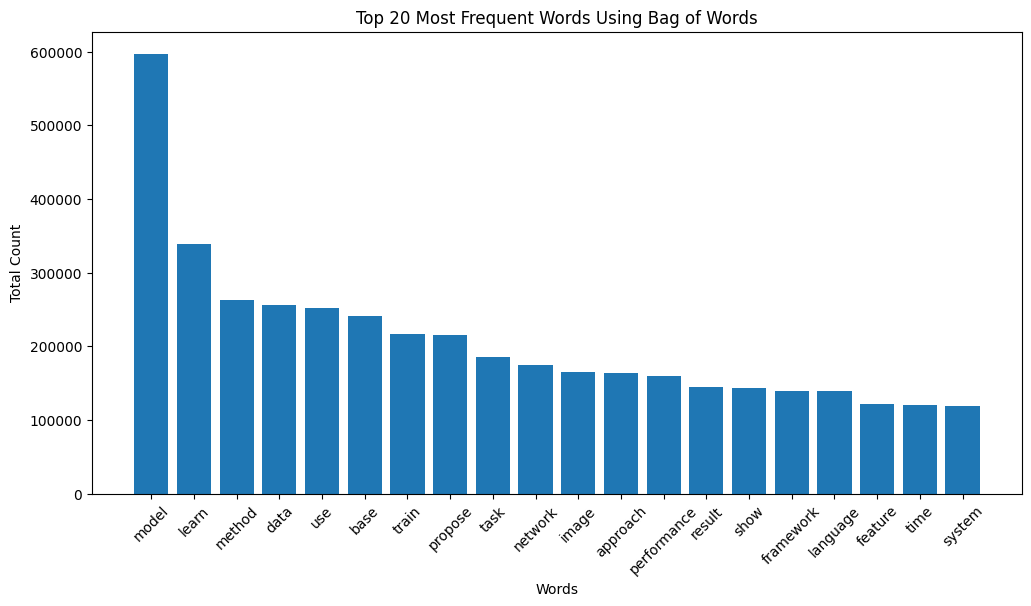

In [ ]:

# Visualize Top 20 Most Frequent Words


top_20_words = word_counts_df.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_20_words["Word"], top_20_words["Total Count"])

plt.title("Top 20 Most Frequent Words Using Bag of Words")
plt.xlabel("Words")
plt.ylabel("Total Count")

plt.xticks(rotation=45)
plt.show()

In [ ]:

# Build TF-IDF


from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Convert cleaned_text into numerical TF-IDF features
X_tfidf = tfidf_vectorizer.fit_transform(df["cleaned_text"].astype(str))

print("TF-IDF created successfully!\n")

# Show the shape of the TF-IDF matrix
print("TF-IDF Matrix Shape:")
print(X_tfidf.shape)

# Show first 20 TF-IDF feature names
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("\nFirst 20 TF-IDF Features:")
print(tfidf_features[:20])

TF-IDF created successfully!

TF-IDF Matrix Shape:
(287421, 5000)

First 20 TF-IDF Features:
['00' '000' '001' '01' '02' '03' '04' '05' '06' '07' '08' '10' '100'
 '1000' '101' '10k' '10x' '11' '12' '120']


In [ ]:

# Display TF-IDF Matrix Sample


tfidf_sample_table = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf_features
)

display(tfidf_sample_table.iloc[:, :20])

,00,000,001,01,02,03,04,05,06,07,08,10,100,1000,101,10k,10x,11,12,120
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:



tfidf_scores = X_tfidf.mean(axis=0)

tfidf_scores_df = pd.DataFrame({
    "Word": tfidf_features,
    "Average TF-IDF Score": tfidf_scores.A1
})

tfidf_scores_df = tfidf_scores_df.sort_values(
    by="Average TF-IDF Score",
    ascending=False
)

display(tfidf_scores_df.head(20))

,Word,Average TF-IDF Score
2882,model,0.043049
2576,learn,0.031501
1189,data,0.026131
2810,method,0.024111
4626,train,0.022598
4805,use,0.022198
3005,network,0.022181
2226,image,0.021896
550,base,0.021584
4495,task,0.020382


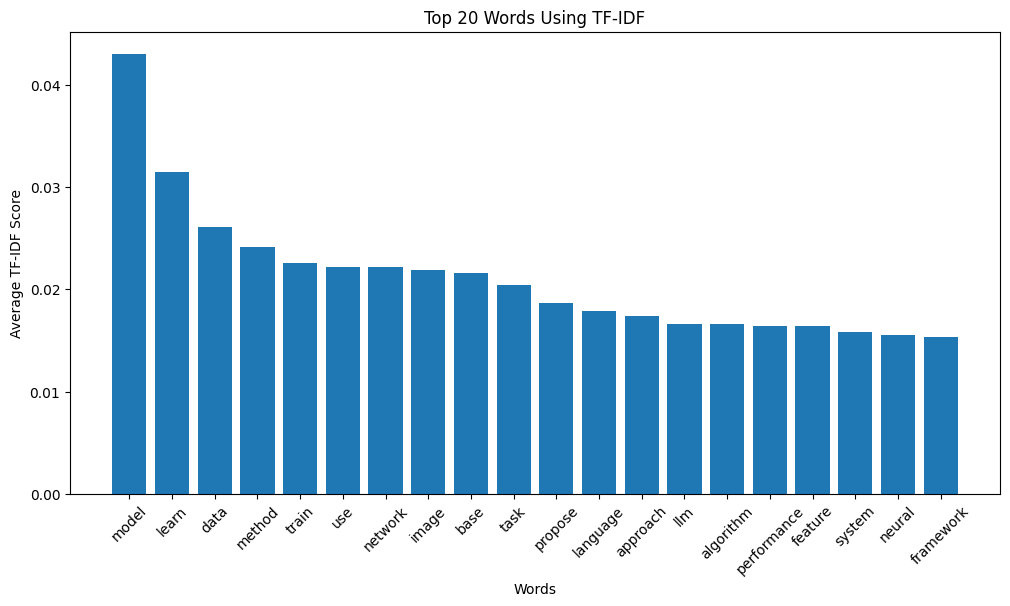

In [ ]:

# Visualize Top 20 TF-IDF Words


top_20_tfidf_words = tfidf_scores_df.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_20_tfidf_words["Word"], top_20_tfidf_words["Average TF-IDF Score"])

plt.title("Top 20 Words Using TF-IDF")
plt.xlabel("Words")
plt.ylabel("Average TF-IDF Score")

plt.xticks(rotation=45)
plt.show()

In [ ]:

#Save TF-IDF Summary


tfidf_summary = {
    "Method": "TF-IDF",
    "Number of Documents": X_tfidf.shape[0],
    "Number of Features": X_tfidf.shape[1],
    "Total Non-Zero Values": X_tfidf.nnz,
    "Matrix Density": X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
}

tfidf_summary_df = pd.DataFrame([tfidf_summary])

display(tfidf_summary_df)

,Method,Number of Documents,Number of Features,Total Non-Zero Values,Matrix Density
0,TF-IDF,287421,5000,23936692,0.016656


In [ ]:

# Step 8: Compare Bag of Words and TF-IDF

comparison_summary = pd.DataFrame({
    "Method": ["Bag of Words", "TF-IDF"],
    "Number of Documents": [X_bow.shape[0], X_tfidf.shape[0]],
    "Number of Features": [X_bow.shape[1], X_tfidf.shape[1]],
    "Total Non-Zero Values": [X_bow.nnz, X_tfidf.nnz],
    "Matrix Density": [
        X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]),
        X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
    ]
})

display(comparison_summary)

,Method,Number of Documents,Number of Features,Total Non-Zero Values,Matrix Density
0,Bag of Words,287421,5000,23936692,0.016656
1,TF-IDF,287421,5000,23936692,0.016656


In [ ]:

# Compare One Paper Using BoW and TF-IDF


paper_index = 0

bow_one_paper = pd.DataFrame({
    "Word": bow_features,
    "BoW Count": X_bow[paper_index].toarray()[0]
})

tfidf_one_paper = pd.DataFrame({
    "Word": tfidf_features,
    "TF-IDF Score": X_tfidf[paper_index].toarray()[0]
})

# Keeps only words that appear in the selected paper
bow_one_paper = bow_one_paper[bow_one_paper["BoW Count"] > 0]
tfidf_one_paper = tfidf_one_paper[tfidf_one_paper["TF-IDF Score"] > 0]

# Merge both results
bow_tfidf_comparison = pd.merge(
    bow_one_paper,
    tfidf_one_paper,
    on="Word",
    how="inner"
)

# Sort by TF-IDF score
bow_tfidf_comparison = bow_tfidf_comparison.sort_values(
    by="TF-IDF Score",
    ascending=False
)

display(bow_tfidf_comparison.head(20))

,Word,BoW Count,TF-IDF Score
2,backtrack,4,0.707294
29,search,3,0.265312
12,erase,1,0.170697
21,point,2,0.157403
3,completeness,1,0.150478
33,space,2,0.139419
32,sometimes,1,0.138723
11,earlier,1,0.138115
30,shallow,1,0.134507
22,polynomial,1,0.127693


In [ ]:



X_final = X_tfidf


final_vectorizer = tfidf_vectorizer


final_features = tfidf_features


final_selection = pd.DataFrame({
    "Selected Method": ["TF-IDF"],
    "Number of Documents": [X_final.shape[0]],
    "Number of Features": [X_final.shape[1]],
    "Purpose": ["Final numerical text representation for ML models"]
})

display(final_selection)

,Selected Method,Number of Documents,Number of Features,Purpose
0,TF-IDF,287421,5000,Final numerical text representation for ML models


In [ ]:
import pickle

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf_vectorizer, file)

print("TF-IDF vectorizer saved successfully as tfidf_vectorizer.pkl")

TF-IDF vectorizer saved successfully as tfidf_vectorizer.pkl


In [ ]:



from scipy.sparse import save_npz

save_npz("tfidf_matrix.npz", X_tfidf)

print("TF-IDF matrix saved successfully as tfidf_matrix.npz")

TF-IDF matrix saved successfully as tfidf_matrix.npz
